# The Cities of Tomorrow – Urban Growth & Sustainability 🏙️

This fabric notebook explores the Sustainable Urban Planning & Landscape Dataset. 

### Project Objective
This notebook explores the factors driving urban sustainability and livability in cities, focusing on:

- How green area availability, renewable energy, and other urban features influence population movement.
- Identifying the top cities to live in, based on data-driven insights.
- Understanding the interplay between urban planning and state-level clean energy trends.


| Title       | Description      |
|----------------|----------------|
| Author | [Abhineet Singh](https://www.linkedin.com/in/abhineetsing/)  |
| Last Modified Date  | 11/6/25  |
| Dataset  | [Link](https://www.kaggle.com/datasets/programmer3/sustainable-urban-planning-and-landscape-dataset)  |

**Additional Data sources:**
- [UN - Open Spaces & Green Areas](https://data.unhabitat.org/pages/open-spaces-and-green-areas)
- [UN - Population & Demographic Trends](https://data.unhabitat.org/pages/urban-population-and-demographic-trends)
- [State and Local Planning for Energy](https://maps.nrel.gov/slope/data-viewer?filters=%5B%5D&layer=stdscen23.low-ccs-cost&year=2020&res=state)

###### Created At: 11/5/2025

#### Key Features Explored

- Green cover percentage 🌳
- Renewable energy usage ♻️
- Public transport access 🚌
- Disaster risk index ⛓️‍💥
- Crime rate index (if available) 🦹
- Carbon footprint 🌫️
- Land use types 🏭
---


## 1. Data Cleaning & Preparation 🧹

In [2]:
import pandas as pd
# Load Kaggle Urban Sustainability data into pandas DataFrame
df = pd.read_csv(f"{notebookutils.nbResPath}/builtin/urban_planning_dataset.csv")
df.head()

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 4, Finished, Available, Finished)

,building_density,road_connectivity,public_transport_access,air_quality_index,green_cover_percentage,carbon_footprint,population_density,crime_rate,avg_income,renewable_energy_usage,disaster_risk_index,land_use_type_Commercial,land_use_type_Green Space,land_use_type_Industrial,land_use_type_Residential,urban_sustainability_score
0,0.367915,0.393821,0.428129,0.414830,0.238555,0.921950,0.126449,0.547160,0.932412,0.382358,0.446242,0.0,0.0,1.0,0.0,0.259239
1,0.414306,0.608445,0.658481,0.490982,0.917681,0.178213,0.325124,0.764042,0.903241,0.377167,0.936824,0.0,1.0,0.0,0.0,0.576923
2,0.827902,0.444679,0.263853,0.264529,0.077883,0.295159,0.042150,0.575736,0.208098,0.237949,0.463054,0.0,0.0,0.0,1.0,0.252844
3,0.733936,0.742708,0.012022,0.486974,0.427303,0.975900,0.663838,0.826727,0.258951,0.876539,0.204293,0.0,0.0,1.0,0.0,0.409002
4,0.769643,0.228268,0.519082,0.945892,0.532321,0.370856,0.429912,0.127542,0.180394,0.679006,0.151421,0.0,0.0,1.0,0.0,0.686376


### Data Overview

- **Shape:** Rows and columns
- **Columns:** building_density, road_connectivity, public_transport_access, air_quality_index, green_cover_percentage, carbon_footprint, population_density, crime_rate, avg_income, renewable_energy_usage, disaster_risk_index, land_use_type_*, urban_sustainability_score

In [3]:
df.info()
df.isnull().sum()

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 5, Finished, Available, Finished)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3476 entries, 0 to 3475
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   building_density            3476 non-null   float64
 1   road_connectivity           3476 non-null   float64
 2   public_transport_access     3476 non-null   float64
 3   air_quality_index           3476 non-null   float64
 4   green_cover_percentage      3476 non-null   float64
 5   carbon_footprint            3476 non-null   float64
 6   population_density          3476 non-null   float64
 7   crime_rate                  3476 non-null   float64
 8   avg_income                  3476 non-null   float64
 9   renewable_energy_usage      3476 non-null   float64
 10  disaster_risk_index         3476 non-null   float64
 11  land_use_type_Commercial    3476 non-null   float64
 12  land_use_type_Green Space   3476 non-null   float64
 13  land_use_type_Industrial    3476 

building_density              0
road_connectivity             0
public_transport_access       0
air_quality_index             0
green_cover_percentage        0
carbon_footprint              0
population_density            0
crime_rate                    0
avg_income                    0
renewable_energy_usage        0
disaster_risk_index           0
land_use_type_Commercial      0
land_use_type_Green Space     0
land_use_type_Industrial      0
land_use_type_Residential     0
urban_sustainability_score    0
dtype: int64

### Data Cleaning Steps (Not Needed as dataset is complete with no Null Values)

- Handle missing values (impute or drop)
- Convert categorical columns if needed
- Normalize/scale features for modeling
---

## 2. Exploratory Data Analysis (EDA) 🔎

We explore the data to understand distributions, relationships, and trends among urban sustainability indicators. This phase helps us generate hypotheses and spot patterns.

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 6, Finished, Available, Finished)

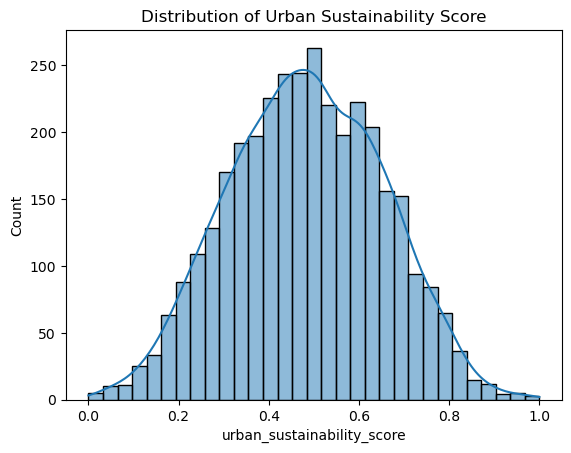

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Urban Sustainability Score
sns.histplot(df['urban_sustainability_score'], kde=True)
plt.title('Distribution of Urban Sustainability Score')
plt.show()


### Key Exploratory Data Analysis

- Which features are most strongly correlated with urban sustainability?


StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 7, Finished, Available, Finished)

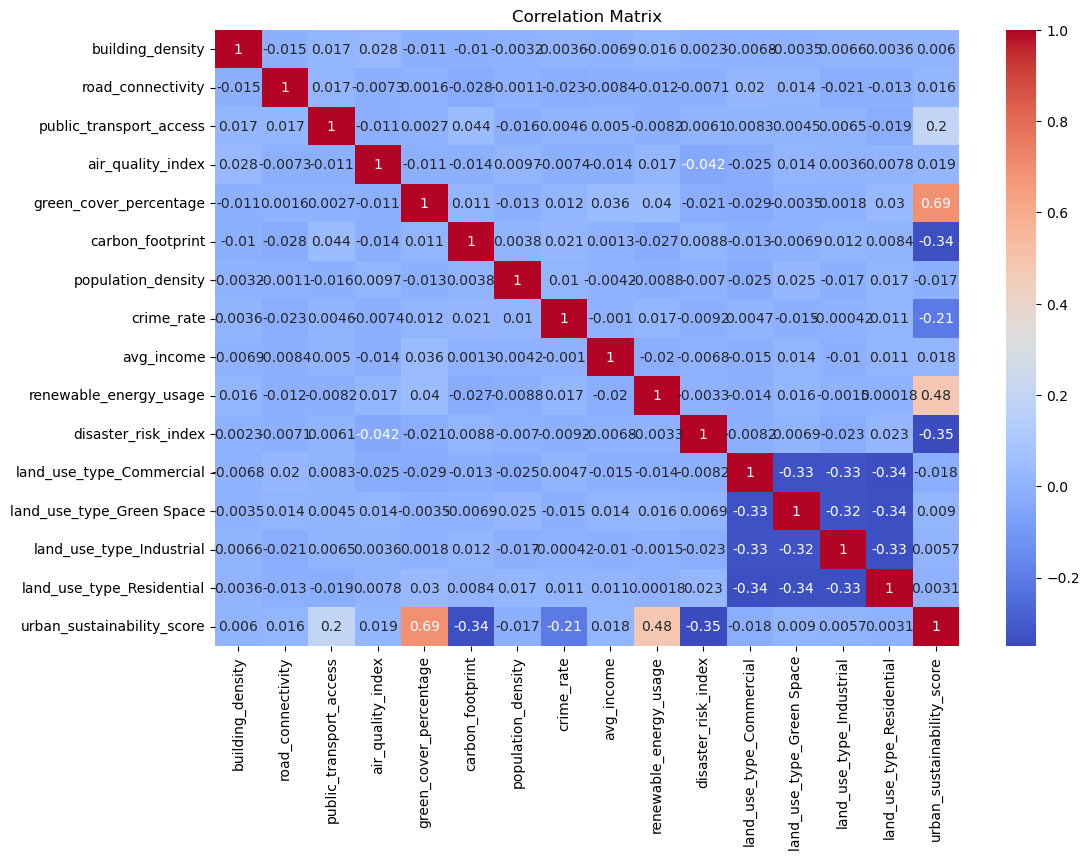

In [5]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#### Pick Top 10 Features to explore further on its significance on positive and negative correlation for analytics purposes.

In [6]:
import numpy as np

# Compute correlation matrix for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Extract upper triangle of the correlation matrix, excluding the diagonal
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Unstack, drop NaNs to get unique correlation pairs
corr_pairs = upper_tri.unstack().dropna()

# Get top 10 positive correlations
top10_pos = corr_pairs.nlargest(10)
print("Top 10 Positive Correlations:")
print(top10_pos)

# Get top 10 negative correlations
top10_neg = corr_pairs.nsmallest(10)
print("\nTop 10 Negative Correlations:")
print(top10_neg)

StatementMeta(, e25b6fc1-bae0-4cb6-9bb4-738476c6f3e7, 8, Finished, Available, Finished)

Top 10 Positive Correlations:
urban_sustainability_score  green_cover_percentage     0.690025
                            renewable_energy_usage     0.481232
                            public_transport_access    0.203036
carbon_footprint            public_transport_access    0.043503
renewable_energy_usage      green_cover_percentage     0.040345
avg_income                  green_cover_percentage     0.035667
land_use_type_Residential   green_cover_percentage     0.030174
air_quality_index           building_density           0.027841
land_use_type_Green Space   population_density         0.024575
land_use_type_Residential   disaster_risk_index        0.023499
dtype: float64

Top 10 Negative Correlations:
urban_sustainability_score  disaster_risk_index         -0.349746
land_use_type_Residential   land_use_type_Commercial    -0.343356
                            land_use_type_Green Space   -0.338382
urban_sustainability_score  carbon_footprint            -0.337701
land_use_type_Reside

#### Generate a Matrix Plot to further understand dominant features behind Urban Sustainability Score.

StatementMeta(, e25b6fc1-bae0-4cb6-9bb4-738476c6f3e7, 10, Finished, Available, Finished)

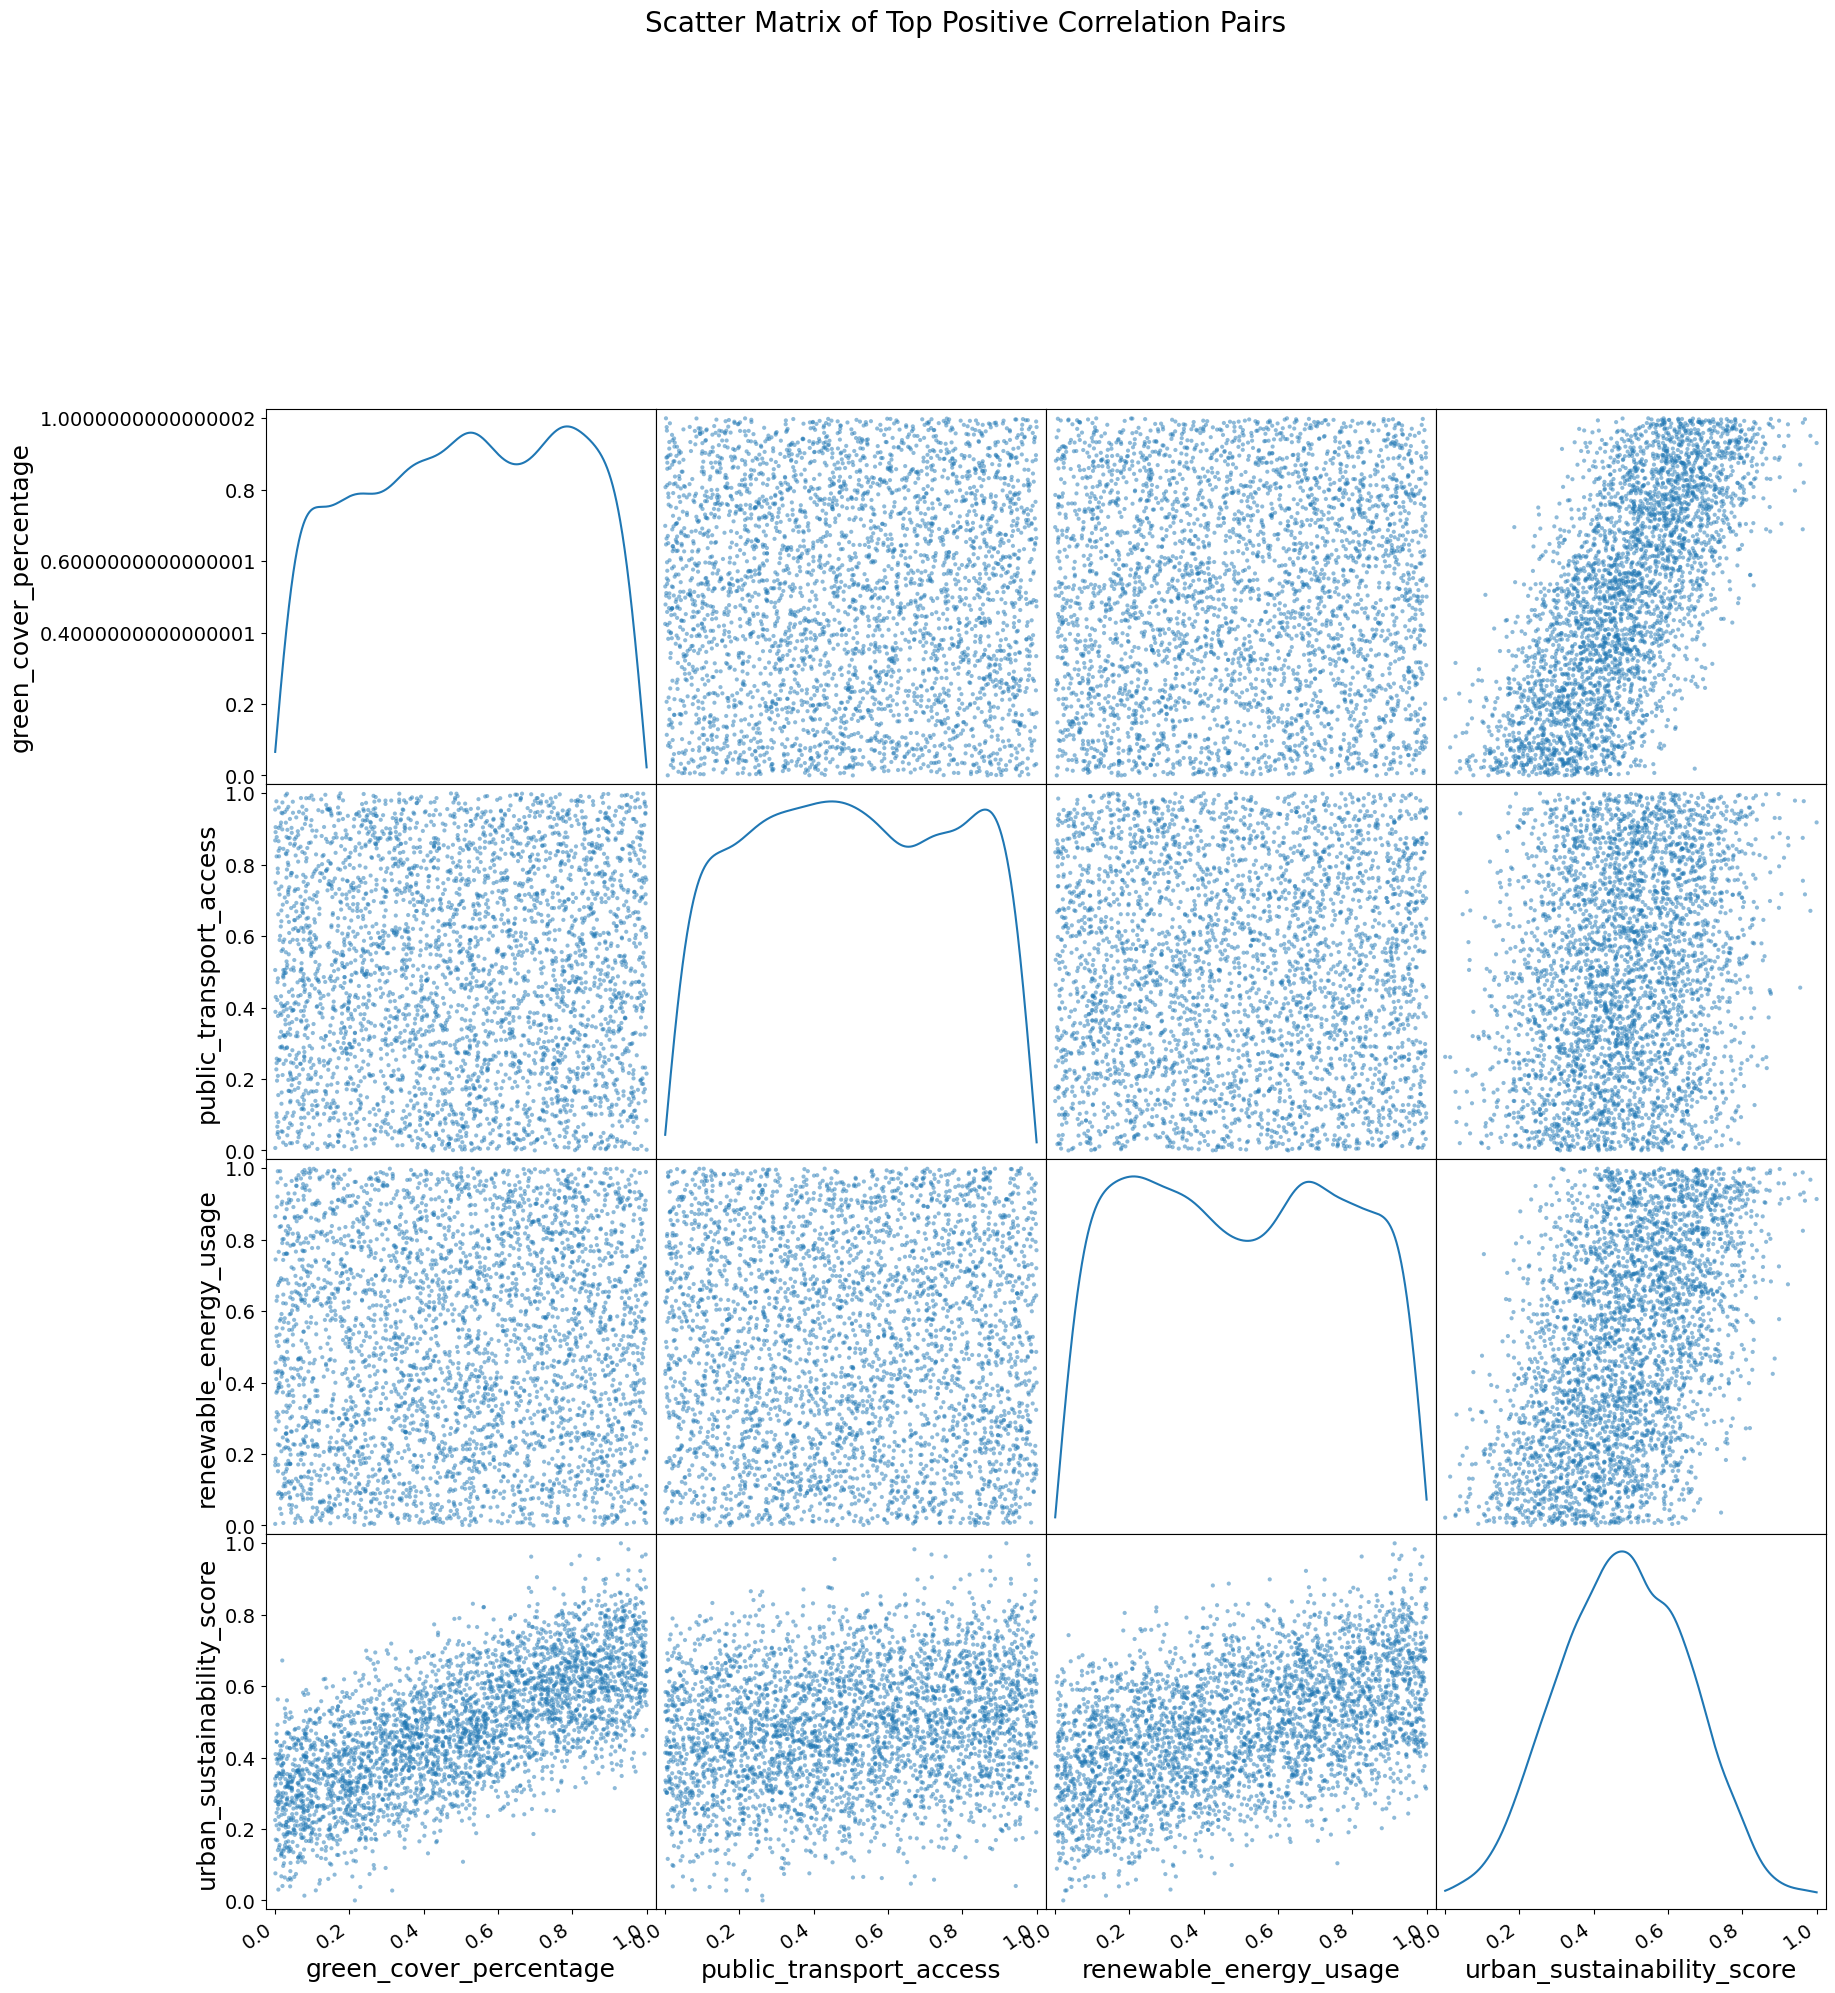

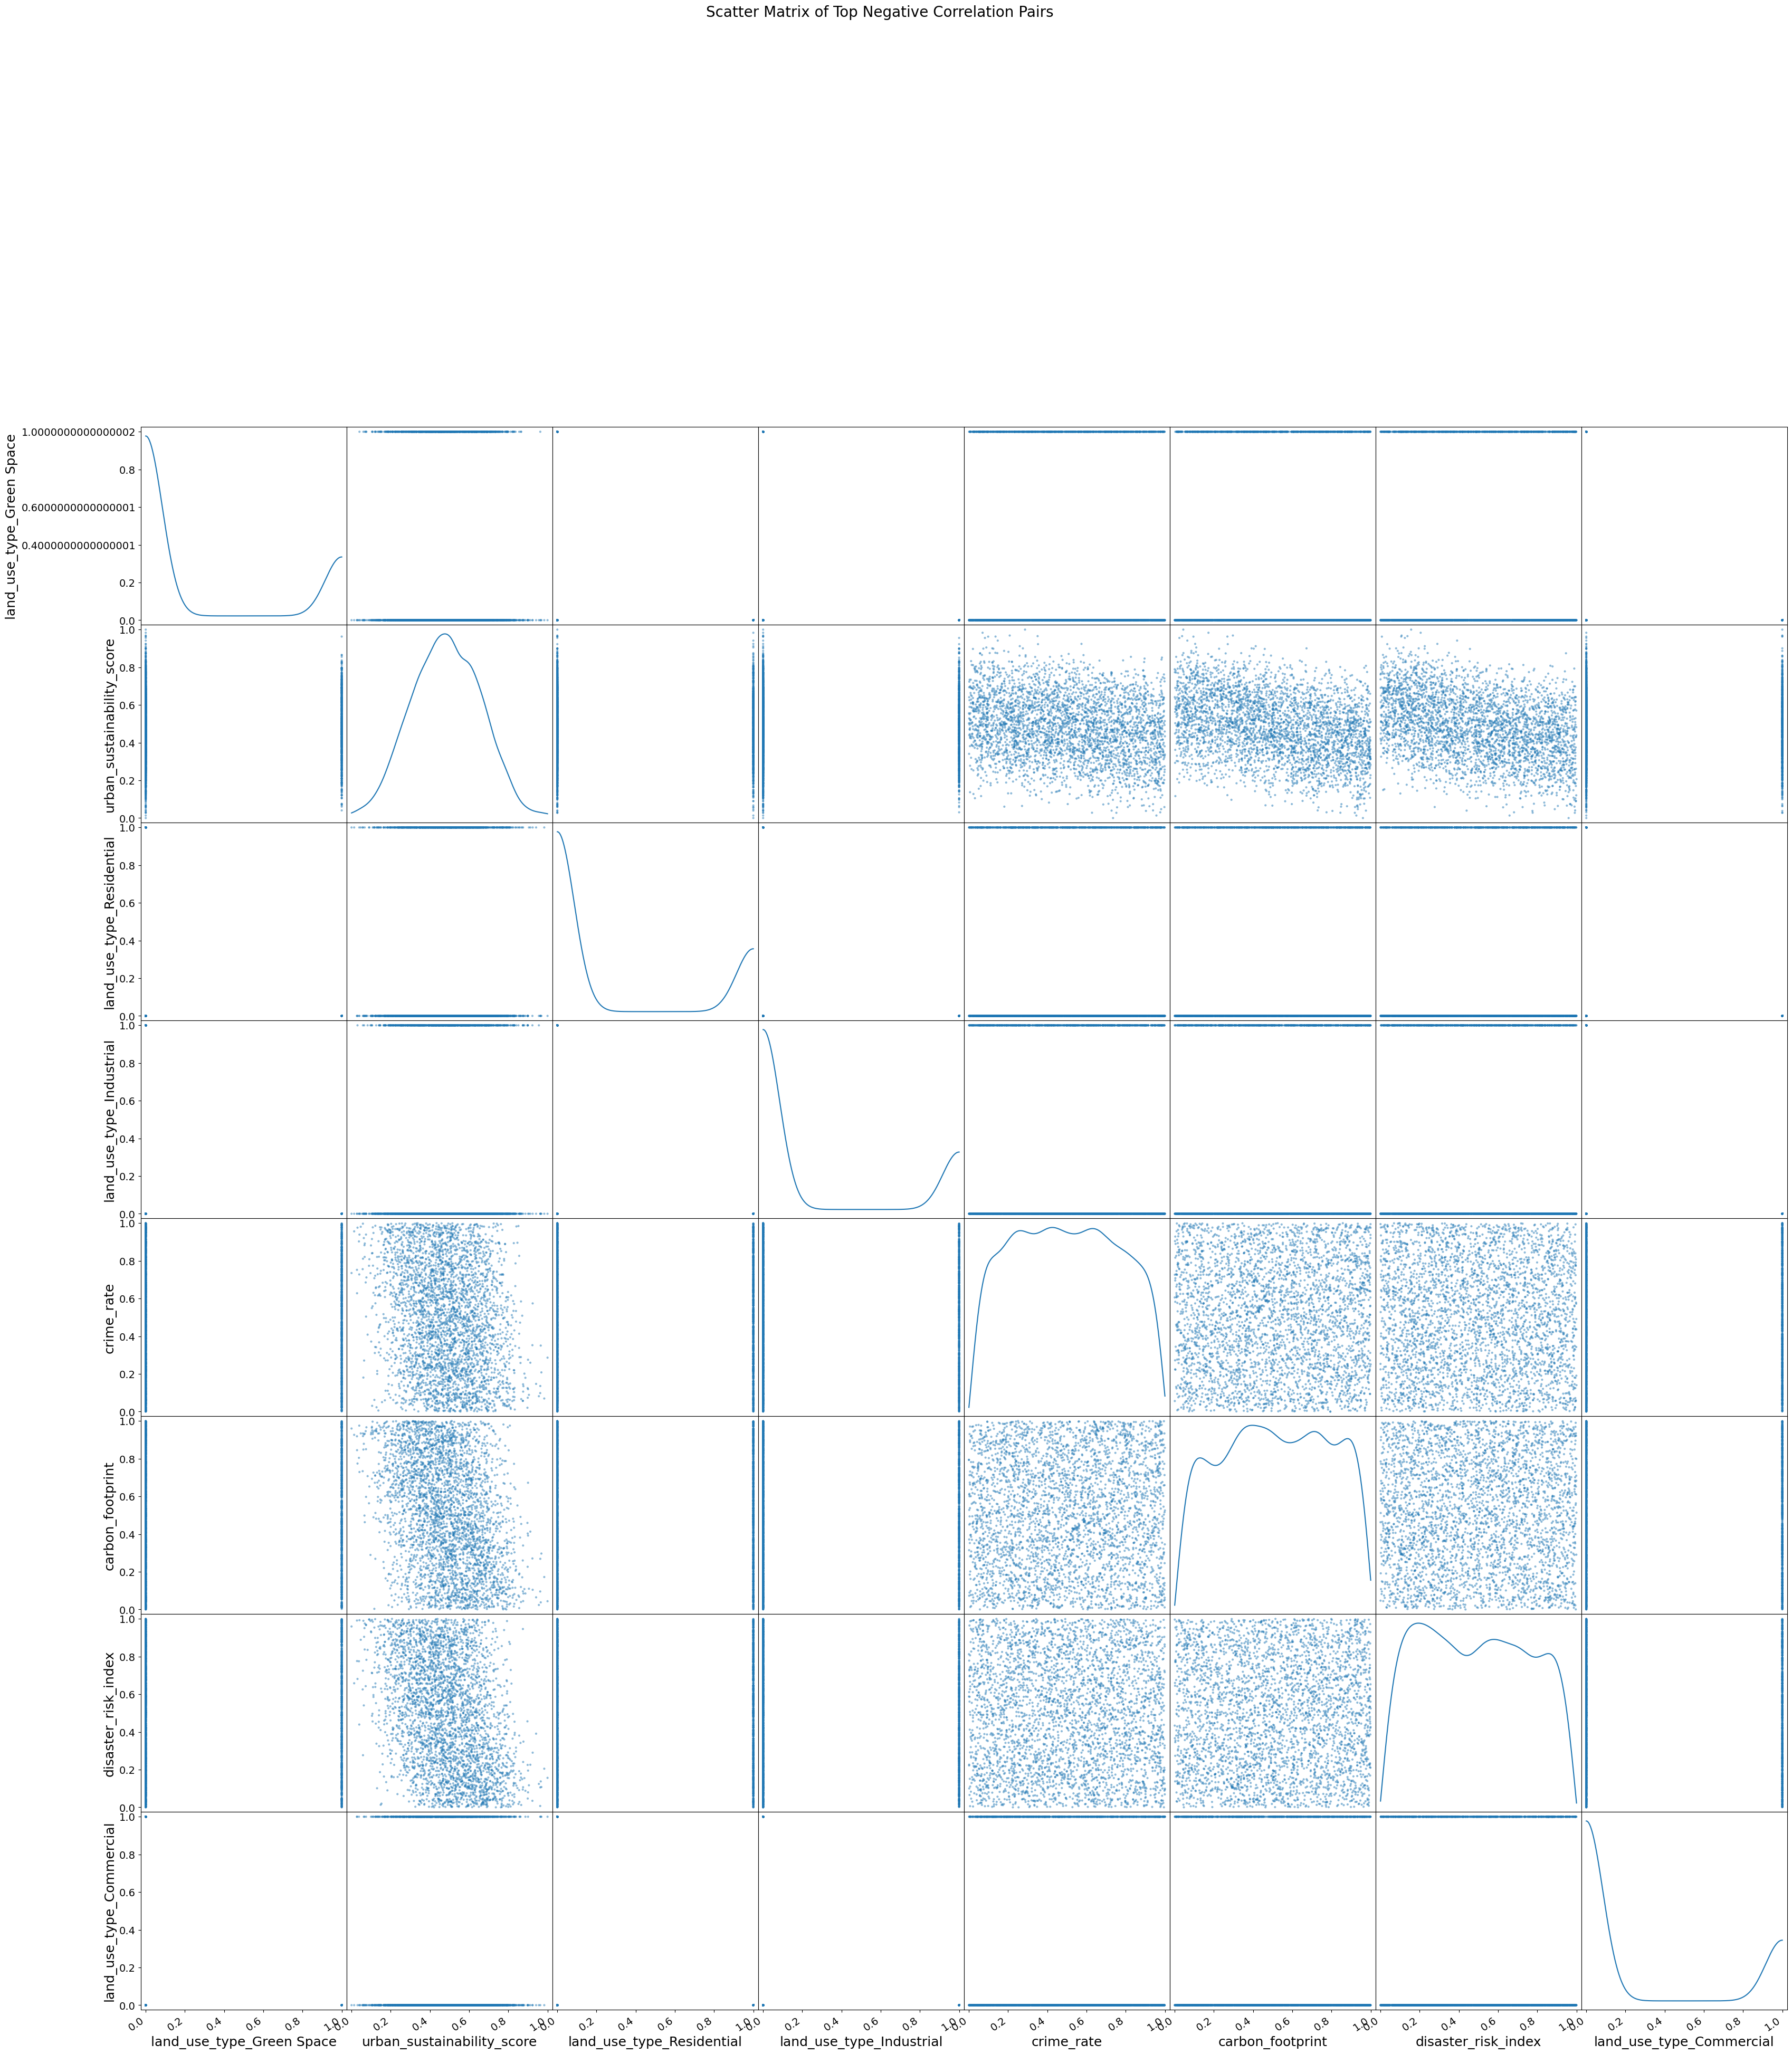

In [8]:

import matplotlib.pyplot as plt
import pandas as pd

# These are the top positive and negative correlation pairs you previously identified
top_pos = [
    ("green_cover_percentage", "urban_sustainability_score"),
    ("renewable_energy_usage", "urban_sustainability_score"),
    ("public_transport_access", "urban_sustainability_score")
]
top_neg = [
    ("urban_sustainability_score", "disaster_risk_index"),
    ("land_use_type_Residential", "land_use_type_Commercial"),
    ("land_use_type_Residential", "land_use_type_Green Space"),
    ("land_use_type_Residential", "land_use_type_Industrial"),
    ("crime_rate", "urban_sustainability_score"),
    ("carbon_footprint", "urban_sustainability_score")
]

def scatter_matrix_for_pairs(df, pairs, title):
    all_cols = list({c for pair in pairs for c in pair if c in df.columns})
    # Increase figure size based on number of columns for clarity
    fig_size = 5 * len(all_cols)
    if len(all_cols) > 1:
        axarr = pd.plotting.scatter_matrix(df[all_cols].dropna(), figsize=(fig_size, fig_size), diagonal="kde")
        plt.suptitle(title, y=1.10, fontsize=20)
        # Dynamically adjust label fontsize and rotation so all variable names fit
        for ax in axarr.ravel():
            plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=14)
            plt.setp(ax.get_yticklabels(), rotation=0, fontsize=14)
            ax.xaxis.label.set_size(18)
            ax.yaxis.label.set_size(18)
        plt.subplots_adjust(bottom=0.15, left=0.15, top=0.90, right=0.93)
        plt.show()
    else:
        print(f"Not enough columns for {title} scatter matrix.")

# Plot positive correlation scatter matrix
scatter_matrix_for_pairs(df, top_pos, "Scatter Matrix of Top Positive Correlation Pairs")

# Plot negative correlation scatter matrix
scatter_matrix_for_pairs(df, top_neg, "Scatter Matrix of Top Negative Correlation Pairs")

---

## 3. Insight Generation 📊

Based on EDA, we summarize key findings about what drives urban sustainability. Highlighting surprising patterns and actionable insights for city planners.

#### Top Factors Influencing The Urban Sustainability Score:


StatementMeta(, e25b6fc1-bae0-4cb6-9bb4-738476c6f3e7, 11, Finished, Available, Finished)

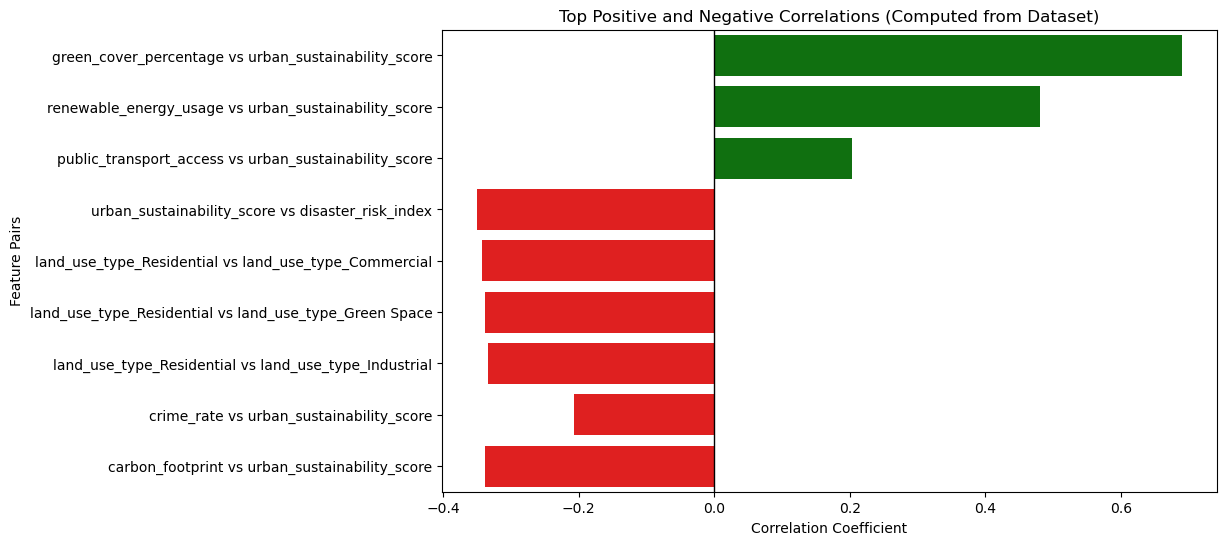

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting some key features correlating to urban sustainability in positive or negative context.
corr_pairs = [
    ('green_cover_percentage', 'urban_sustainability_score'),
    ('renewable_energy_usage', 'urban_sustainability_score'),
    ("public_transport_access", "urban_sustainability_score"),
    ("urban_sustainability_score", "disaster_risk_index"),
    ("land_use_type_Residential", "land_use_type_Commercial"),
    ("land_use_type_Residential", "land_use_type_Green Space"),
    ("land_use_type_Residential", "land_use_type_Industrial"),
    ("crime_rate", "urban_sustainability_score"),
    ("carbon_footprint", "urban_sustainability_score")
]

corr_scores = []
corr_labels = []

for col1, col2 in corr_pairs:
    if col1 in df.columns and col2 in df.columns:
        score = df[[col1, col2]].corr().iloc[0,1]
        corr_scores.append(score)
        corr_labels.append(f'{col1} vs {col2}')

# Colors: green = positive, red = negative
palette = ['green' if v > 0 else 'red' for v in corr_scores]

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_scores, y=corr_labels, palette=palette)
plt.title('Top Positive and Negative Correlations (Computed from Dataset)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature Pairs')
plt.axvline(0, color='black', linewidth=1)
plt.show()

#### Refined Correlation Matrix

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 8, Finished, Available, Finished)

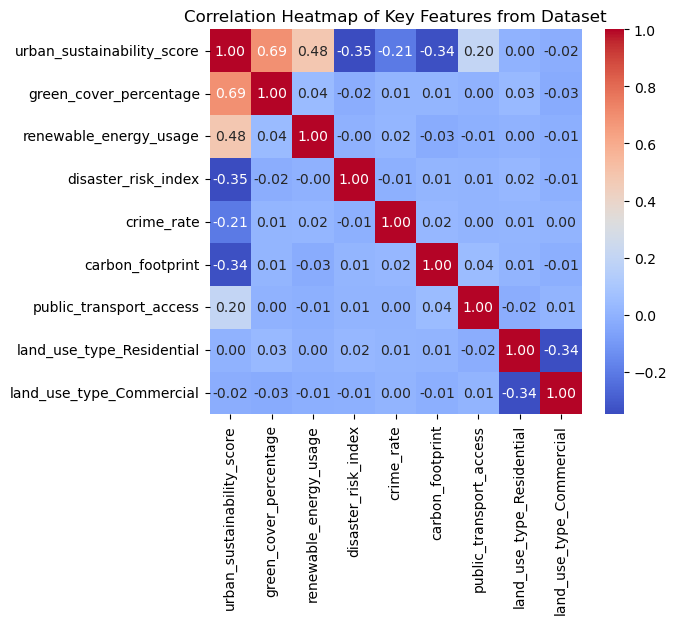

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Simplifying correlation matrix to key features
corr_features = [
    'urban_sustainability_score',
    'green_cover_percentage',
    'renewable_energy_usage',
    'disaster_risk_index',
    'crime_rate',
    'carbon_footprint',
    'public_transport_access',
    'land_use_type_Residential',
    'land_use_type_Commercial'

]

existing_corr_features = [col for col in corr_features if col in df.columns]

# Compute the correlation matrix for these features
corr_df = df[existing_corr_features].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Features from Dataset')
plt.show()

#### Plot Trends OF Some of the Features - That can be used for Urban Sustainability Score Prediction

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 9, Finished, Available, Finished)

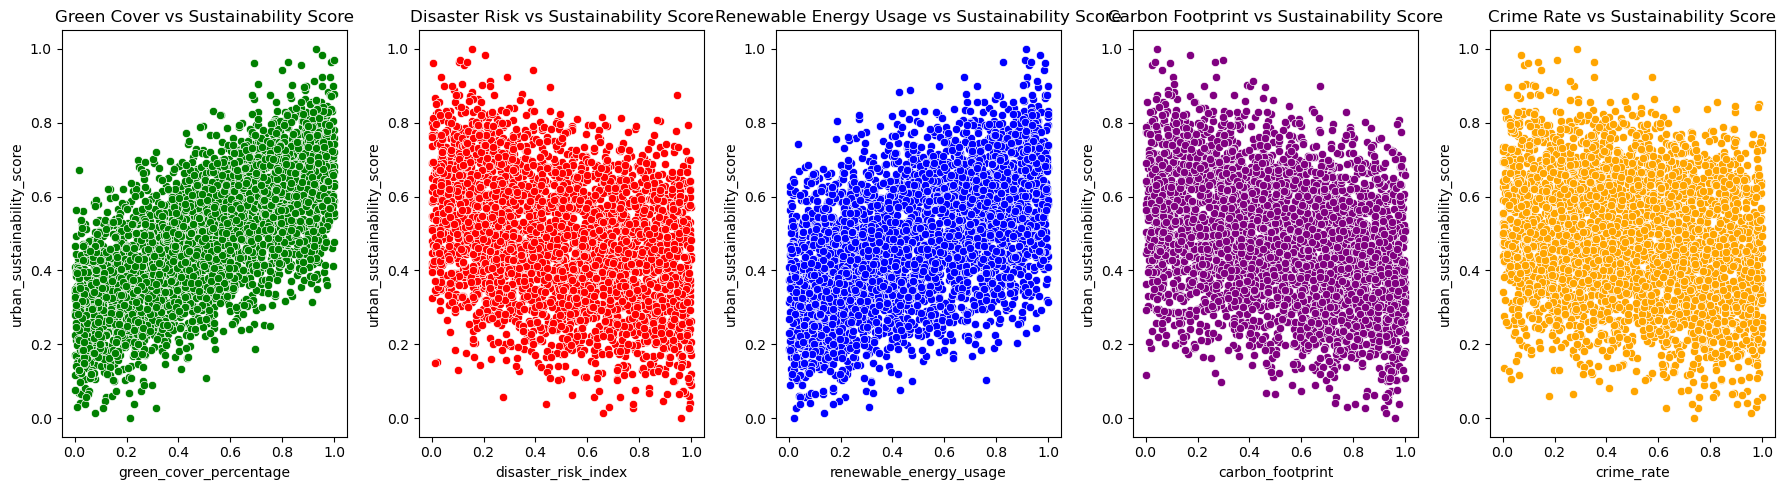

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Influencing Factors Plots
cols_to_plot = [
    ('green_cover_percentage', 'urban_sustainability_score', 'green', 'Green Cover vs Sustainability Score'),
    ('disaster_risk_index', 'urban_sustainability_score', 'red', 'Disaster Risk vs Sustainability Score'),
    ('renewable_energy_usage', 'urban_sustainability_score', 'blue', 'Renewable Energy Usage vs Sustainability Score'),
    ('carbon_footprint', 'urban_sustainability_score', 'purple', 'Carbon Footprint vs Sustainability Score'),
    ('crime_rate', 'urban_sustainability_score', 'orange', 'Crime Rate vs Sustainability Score')
]
valid_plots = [(x, y, color, title) for x, y, color, title in cols_to_plot if x in df.columns and y in df.columns]

fig, axes = plt.subplots(1, len(valid_plots), figsize=(18, 5))

if len(valid_plots) == 1:
    axes = [axes]  # Ensure axes is iterable

for idx, (x, y, color, title) in enumerate(valid_plots):
    sns.scatterplot(x=x, y=y, data=df, ax=axes[idx], color=color)
    axes[idx].set_title(title)

plt.tight_layout()
plt.show()

## Key Highlights Post EDA 📢

- **Boost green spaces and renewable energy adoption** → These are the strongest levers for improving sustainability.
- **Invest in public transport** → Even moderate improvements reduce carbon footprint and enhance livability.
- **Mitigate disaster risks and emissions** → Urban resilience and carbon reduction strategies are essential.
- **Balance land use** → Avoid over-concentration of residential or commercial zones; preserve green areas.

---


## 4. Predictive Modeling 🧪

A predictive model to estimate urban sustainability scores based on the available indicators. To help guide urban policy and planning.


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Select features and target
features = [col for col in df.columns if col != 'urban_sustainability_score']
X = df[features]
y = df['urban_sustainability_score']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R^2:', r2_score(y_test, y_pred))

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 13, Finished, Available, Finished)

RMSE: 0.041445854167837505
R^2: 0.9432910707339319


### Feature Importance

We examine which features are most important for predicting sustainability, providing actionable levers for urban improvement.

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 14, Finished, Available, Finished)

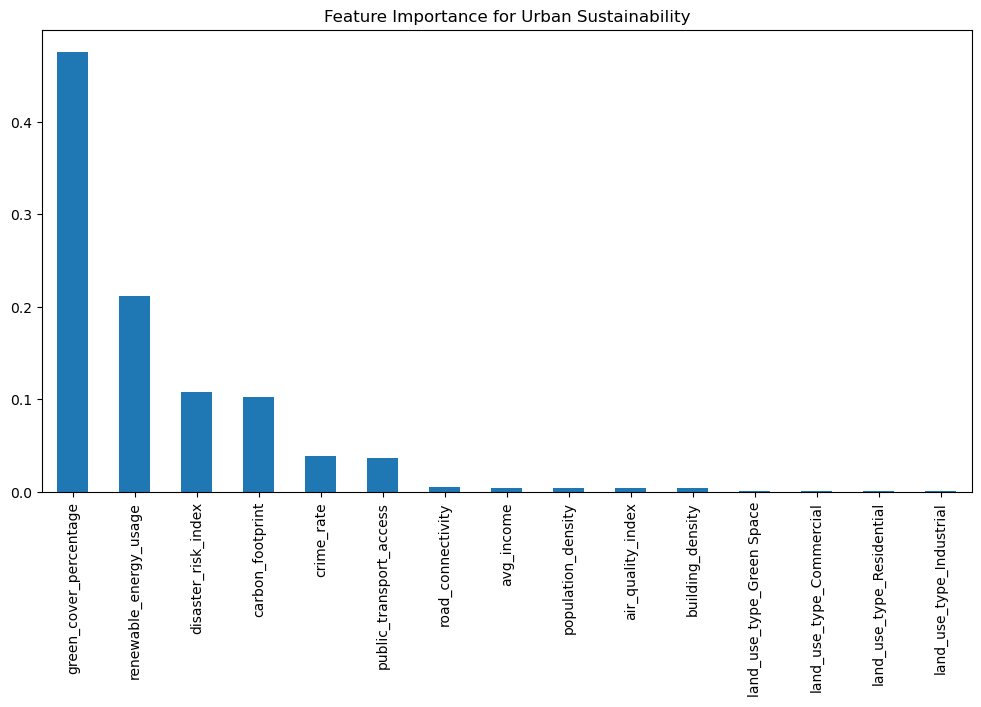

In [12]:
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=features).sort_values(ascending=False)
feature_importance.plot(kind='bar', figsize=(12,6))
plt.title('Feature Importance for Urban Sustainability')
plt.show()

## 5. Conclusions & Recommendations

**Top drivers of urban sustainability:**
- **Boost green spaces and renewable energy adoption** → These are the strongest levers for improving sustainability.
- **Invest in public transport** → Even moderate improvements reduce carbon footprint and enhance livability.
- **Mitigate disaster risks and emissions** → Urban resilience and carbon reduction strategies are essential.
- **Balance land use** → Avoid over-concentration of residential or commercial zones; preserve green areas.
- **Policy recommendations:** Increase green cover, invest in renewable energy, improve transport infrastructure, and reduce pollution.
- **Next steps:** Integrate external data (World Bank, UN-Habitat) for benchmarking; explore causal inference and scenario modeling.

---

## Bonus EDA On U.S Cities where Sustainability Score are high causing population drift.

In [46]:
# Load data into pandas DataFrame
df_population = pd.read_csv(f"{notebookutils.nbResPath}/builtin/Annual_Rate_Population_Change_Pct_Urban_Agglomeration.csv")
df_population.head(10)

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 51, Finished, Available, Finished)

,Country or area,Urban Agglomeration,Unit,1995-2000,2000-2005,2005-2010,2010-2015,2015-2020,2020-2025,2025-2030,2030-2035
0,United States of America,Akron,Percent,0.73,- 0.01,- 0.01,- 0.01,- 0.14,0.20,0.79,0.84
1,United States of America,Albany,Percent,0.92,0.62,0.62,0.62,0.48,0.54,0.85,0.84
2,United States of America,Albuquerque,Percent,1.87,2.15,2.15,2.15,1.95,1.34,0.99,0.85
3,United States of America,Allentown-Bethlehem,Percent,3.30,1.42,1.42,1.42,1.25,0.96,0.92,0.85
4,United States of America,Ann Arbor,Percent,2.37,0.75,0.75,0.75,0.60,0.60,0.86,0.84
5,United States of America,Antioch,Percent,7.86,2.44,2.44,2.44,2.23,1.49,1.02,0.85
6,United States of America,Asheville,Percent,6.74,2.36,2.36,2.36,2.16,1.46,1.01,0.85
7,United States of America,Atlanta,Percent,4.72,2.55,2.55,2.55,2.34,1.55,1.03,0.85
8,United States of America,Augusta-Richmond County,Percent,1.57,1.42,1.42,1.42,1.25,0.96,0.92,0.85
9,United States of America,Austin,Percent,4.70,4.12,4.13,4.13,3.87,2.39,1.17,0.86


In [45]:

# Load data into pandas DataFrame
df_green_area = pd.read_csv(f"{notebookutils.nbResPath}/builtin/Share_Of_Green_Area_Per_Capita_City_Urban.csv")
df_green_area.head(10)


StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 50, Finished, Available, Finished)

,Country or Territory Name,City Code,City Name,SDG Sub-Region,SDG Region,Average share of green area in city/urban area 1990 (%),Average share of green area in city/ urban area 2000 (%),Average share of green area in city/ urban area 2010 (%),Average share of green area in city/ urban area 2020 (%),Green area per capita 1990 (m2/person),Green area per capita 2000 (m2/person),Green area per capita 2010 (m2/person),Green area per capita 2020 (m2/person)
0,United States of America,US_WINSTON_SALEM,Winston-Salem,Northern America,Northern America and Europe,24.17,38.09,41.31,46.95,394.24,430.97,406.68,410.58
1,United States of America,US_AUSTIN_TX,Austin,Northern America,Northern America and Europe,25.48,40.73,38.21,43.22,420.25,420.00,290.22,219.65
2,United States of America,US_CLEVELAND_OH,Cleveland,Northern America,Northern America and Europe,35.76,31.68,45.64,43.18,257.18,223.29,337.60,335.05
3,United States of America,US_RALEIGH_NC,Raleigh,Northern America,Northern America and Europe,45.02,40.96,43.04,42.10,"1,017.35",586.90,427.84,298.67
4,United States of America,US_SAVANNAH_GA,Savannah,Northern America,Northern America and Europe,45.82,43.80,38.98,41.95,574.99,557.18,432.81,406.56
5,United States of America,US_ATLANTA,Atlanta,Northern America,Northern America and Europe,42.76,41.85,42.38,41.04,652.68,420.03,364.01,293.96
6,United States of America,US_COLUMBIA_SOUTH_CAROLINA,"Columbia, South Carolina",Northern America,Northern America and Europe,38.31,37.43,38.07,40.43,565.03,459.89,389.61,346.29
7,United States of America,US_CHARLOTTE,Charlotte,Northern America,Northern America and Europe,41.47,39.40,42.26,39.72,818.86,566.50,449.72,342.20
8,United States of America,US_TOLEDO_OH,Toledo,Northern America,Northern America and Europe,30.15,35.17,32.24,37.92,381.22,442.32,410.93,489.73
9,United States of America,US_CHARLESTON,Charleston,Northern America,Northern America and Europe,15.56,27.49,22.96,37.57,164.01,289.07,207.47,286.15


The schema for df_green_area is 1112.8 tokens long, and may be truncated. The copilot may be unaware of some information.


In [63]:
df_cities = pd.read_csv(f"{notebookutils.nbResPath}/builtin/uscities.csv")
df_cities = df_cities.rename(columns={'city': 'City Name'})
# Filter rows where certain cities are looked at for urban sustainability score
df_cities = df_cities[(df_cities['state_name']=='Illinois') & (df_cities['City Name']=='Chicago') |
                      (df_cities['state_name']=='Texas') & (df_cities['City Name']=='Dallas') |
                      (df_cities['state_name']=='Texas') & (df_cities['City Name']=='Austin') |
                      (df_cities['state_name']=='North Carolina') & (df_cities['City Name']=='Charlotte') |
                      (df_cities['state_name']=='Ohio') & (df_cities['City Name']=='Cleveland') |
                      (df_cities['state_name']=='Ohio') & (df_cities['City Name']=='Toledo') |
                      (df_cities['state_name']=='Georgia') & (df_cities['City Name']=='Atlanta')
                     ]

df_cities.head(10)

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 69, Finished, Available, Finished)

,City Name,city_ascii,state_id,state_name,county_fips,county_name,lat,lng,population,density,source,military,incorporated,timezone,ranking,zips,id
2,Chicago,Chicago,IL,Illinois,17031,Cook,41.8375,-87.6866,8489066,4590.3,shape,False,True,America/Chicago,1,60018 60649 60641 60640 60643 60642 60645 6064...,1840000494
5,Dallas,Dallas,TX,Texas,48113,Dallas,32.7935,-96.7667,5843632,1477.1,shape,False,True,America/Chicago,1,75098 75287 75230 75231 75236 75237 75235 7525...,1840019440
7,Atlanta,Atlanta,GA,Georgia,13121,Fulton,33.7628,-84.4220,5211164,1424.8,shape,False,True,America/New_York,1,30334 30331 30332 30309 30308 30354 30327 3032...,1840013660
27,Austin,Austin,TX,Texas,48453,Travis,30.3005,-97.7522,1915031,1144.9,shape,False,True,America/Chicago,1,78749 78748 78741 78742 78745 78744 78747 7874...,1840019590
36,Cleveland,Cleveland,OH,Ohio,39035,Cuyahoga,41.4764,-81.6805,1679247,1825.4,shape,False,True,America/New_York,1,44135 44120 44119 44113 44112 44111 44110 4411...,1840000596
39,Charlotte,Charlotte,NC,North Carolina,37119,Mecklenburg,35.2083,-80.8303,1436613,1098.2,shape,False,True,America/New_York,1,28269 28262 28105 28280 28282 28209 28208 2820...,1840014557
88,Toledo,Toledo,OH,Ohio,39095,Lucas,41.6638,-83.5827,492076,1287.8,shape,False,True,America/New_York,2,43615 43614 43611 43613 43612 43607 43610 4360...,1840000572


The schema for df_cities is 1207.7 tokens long, and may be truncated. The copilot may be unaware of some information.


In [64]:
import plotly.express as px
# Create a color dictionary for consistent legend
import matplotlib.cm as cm
import matplotlib.colors as mcolors

cities = ['Austin', 'Atlanta','Toledo','Charlotte','Cleveland','Dallas','Chicago']
df_map = df_green_area[df_green_area['City Name'].str.contains('|'.join(cities), case=False, na=False)]
colors = cm.get_cmap('tab10', len(cities))
city_colors = {city: mcolors.rgb2hex(colors(i)) for i, city in enumerate(cities)}
# Use 2020 green area share
year_col = [col for col in df_map.columns if '2020' in col and 'Average share' in col][0]

df_map = pd.merge(df_map, df_cities, on='City Name')

# Assume df_map has 'Latitude', 'Longitude', 'City Name', and year_col
fig = px.scatter_mapbox(
    df_map,
    lat='lat',
    lon='lng',
    color='City Name',
    size=year_col,
    hover_name='City Name',
    hover_data={year_col: True},
    color_discrete_map=city_colors,
    zoom=3,
    height=600
)
fig.update_layout(mapbox_style="carto-positron")
fig.update_layout(title="Green Area Share (2020) in Selected US Cities")
fig.show()


StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 70, Finished, Available, Finished)

/tmp/ipykernel_5887/3241061488.py:8: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
The schema for df_map is 2051.4 tokens long, and may be truncated. The copilot may be unaware of some information.


StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 73, Finished, Available, Finished)

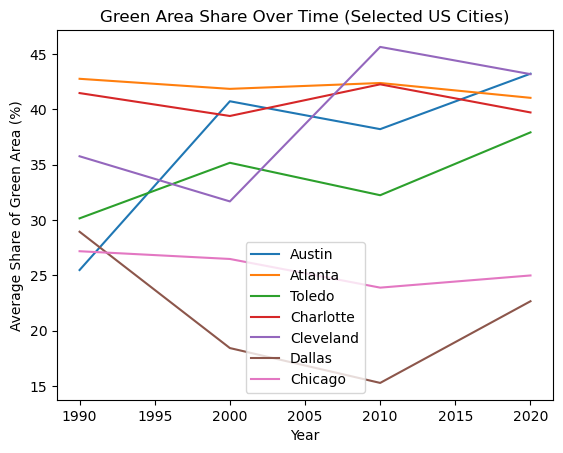

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean and unify column names (remove extra spaces inside and around)
df_green_area.columns = [col.strip().replace("  ", " ").replace(" / ", "/").replace("city/ urban", "city/urban") for col in df_green_area.columns]

# Identify actual year column names present in the dataframe
possible_year_cols = [
    'Average share of green area in city/urban area 1990 (%)',
    'Average share of green area in city/ urban area 2000 (%)',
    'Average share of green area in city/ urban area 2010 (%)',
    'Average share of green area in city/ urban area 2020 (%)',
    'Average share of green area in city/urban area 2000 (%)',
    'Average share of green area in city/urban area 2010 (%)',
    'Average share of green area in city/urban area 2020 (%)'
]
year_columns = [col for col in possible_year_cols if col in df_green_area.columns]
years = [int(s.split()[-2]) for s in year_columns]

# Select a few representative cities
cities = ['Austin', 'Atlanta','Toledo','Charlotte','Cleveland','Dallas','Chicago']
for city in cities:
    city_data = df_green_area[df_green_area['City Name'].str.contains(city, case=False, na=False)]
    if not city_data.empty and all(col in city_data.columns for col in year_columns):
        plt.plot(
            years,
            city_data.iloc[0][year_columns].astype(float),
            label=city
        )

plt.title('Green Area Share Over Time (Selected US Cities)')
plt.xlabel('Year')
plt.ylabel('Average Share of Green Area (%)')
plt.legend()
plt.show()

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 74, Finished, Available, Finished)

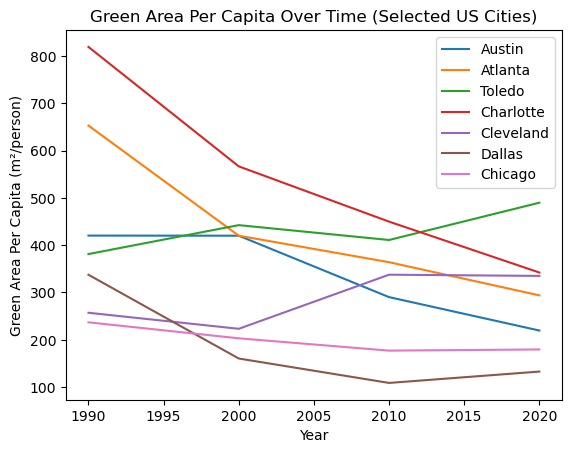

In [68]:
# Identify actual year column names present in the dataframe
possible_year_cols = [
    'Green area per capita 1990 (m2/person)',
    'Green area per capita 2000 (m2/person)',
    'Green area per capita 2010 (m2/person)',
    'Green area per capita 2020 (m2/person)'
]
year_columns = [col for col in possible_year_cols if col in df_green_area.columns]
years = [int(s.split()[-2]) for s in year_columns]

# Select a few representative cities
cities = ['Austin', 'Atlanta','Toledo','Charlotte','Cleveland','Dallas','Chicago']
for city in cities:
    city_data = df_green_area[df_green_area['City Name'].str.contains(city, case=False, na=False)]
    if not city_data.empty and all(col in city_data.columns for col in year_columns):
        plt.plot(
            years,
            city_data.iloc[0][year_columns].astype(float),
            label=city
        )

plt.title('Green Area Per Capita Over Time (Selected US Cities)')
plt.xlabel('Year')
plt.ylabel('Green Area Per Capita (m²/person)')
plt.legend()
plt.show()

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 75, Finished, Available, Finished)

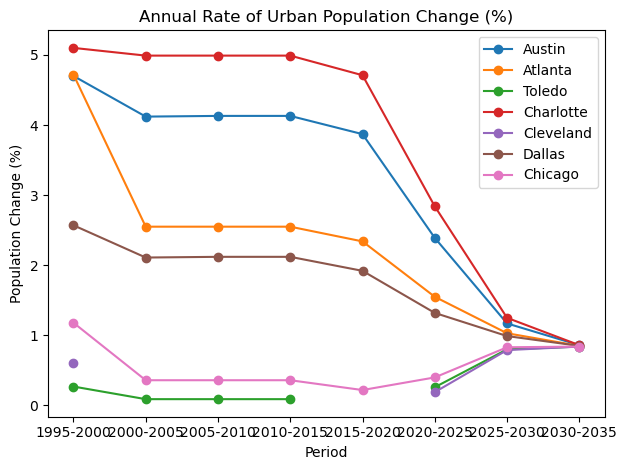

In [69]:
import matplotlib.pyplot as plt

# Strip whitespace from column names to avoid ambiguous datakey errors
df_population.columns = [col.strip() for col in df_population.columns]

periods = ['1995-2000', '2000-2005', '2005-2010', '2010-2015', '2015-2020', '2020-2025', '2025-2030', '2030-2035']

for city in cities:
    city_data = df_population[df_population['Urban Agglomeration'].str.contains(city, case=False, na=False)]
    if not city_data.empty:
        # Safely convert all values to float and coerce errors to NaN, then plot
        values = city_data.iloc[0][periods]
        values = pd.to_numeric(values, errors='coerce')
        plt.plot(periods, values, label=city, marker='o')

plt.title('Annual Rate of Urban Population Change (%)')
plt.xlabel('Period')
plt.ylabel('Population Change (%)')
plt.legend()
plt.tight_layout()
plt.show()

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 76, Finished, Available, Finished)

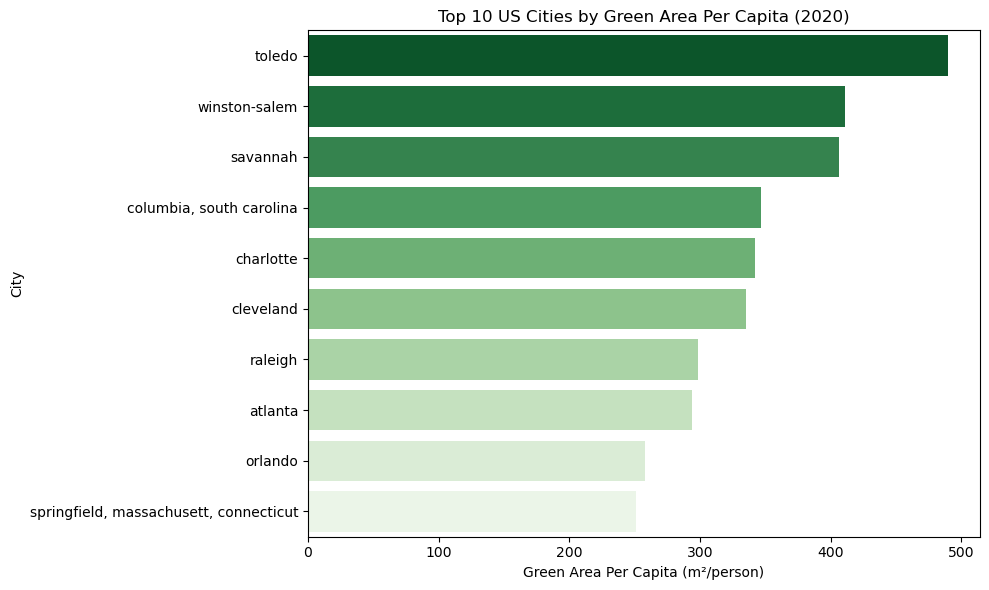

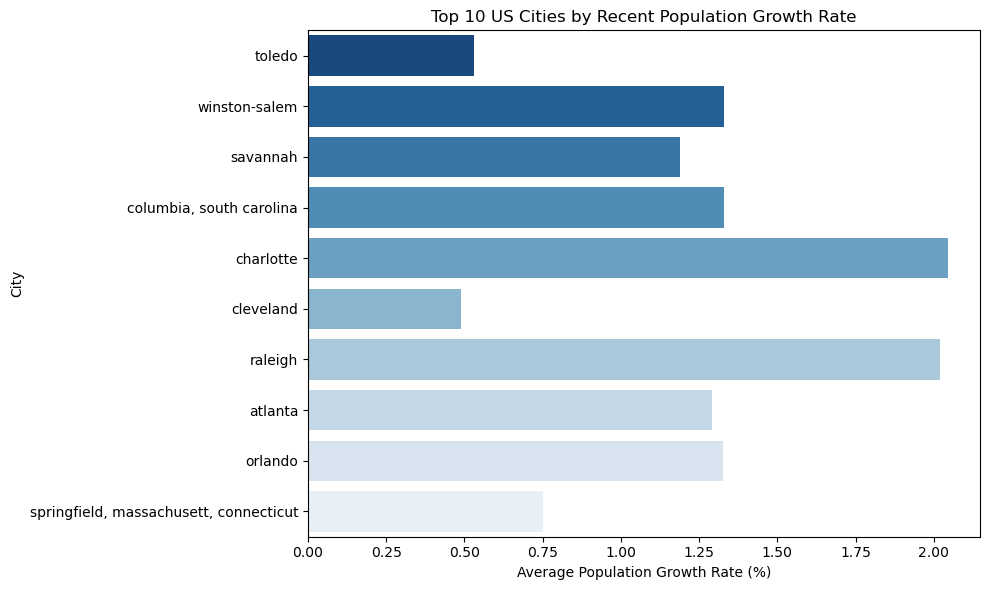

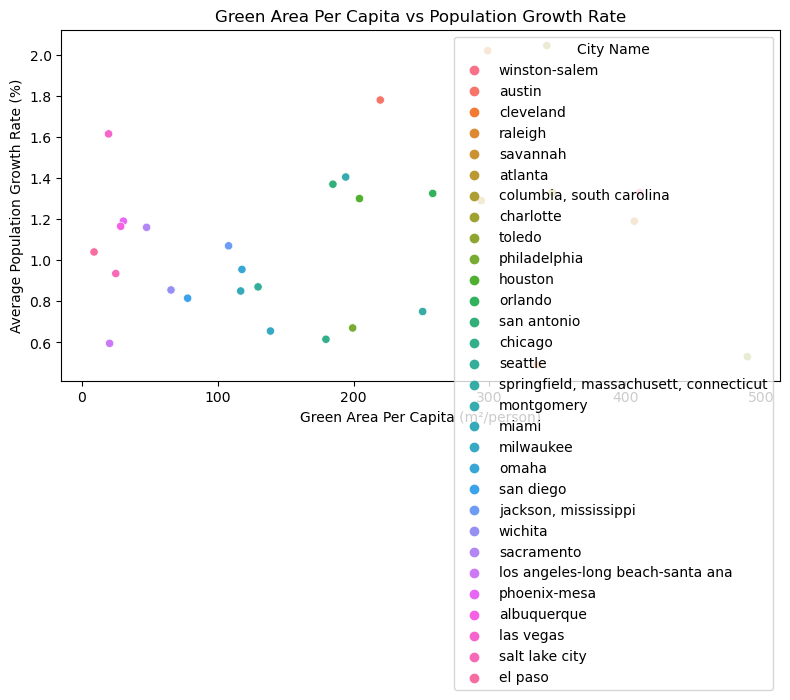

Top 10 Cities Where Population is Moving Due to Green Area Availability:
                                 City Name  \
8                                   toledo   
0                            winston-salem   
4                                 savannah   
6                 columbia, south carolina   
7                                charlotte   
2                                cleveland   
3                                  raleigh   
5                                  atlanta   
11                                 orlando   
15  springfield, massachusett, connecticut   

    Green area per capita 2020 (m2/person)  \
8                                   489.73   
0                                   410.58   
4                                   406.56   
6                                   346.29   
7                                   342.20   
2                                   335.05   
3                                   298.67   
5                                   293.96   
11    

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
green_df = pd.read_csv(f"{notebookutils.nbResPath}/builtin/Share_Of_Green_Area_Per_Capita_City_Urban.csv")
pop_df = pd.read_csv(f"{notebookutils.nbResPath}/builtin/Annual_Rate_Population_Change_Pct_Urban_Agglomeration.csv")

# Standardize city names for merging
green_df['City Name'] = green_df['City Name'].str.strip().str.lower()
pop_df['Urban Agglomeration'] = pop_df['Urban Agglomeration'].str.strip().str.lower()

# Select relevant columns
green_df_2020 = green_df[['City Name', 'Green area per capita 2020 (m2/person)', 'Average share of green area in city/ urban area 2020 (%)']]
pop_df_recent = pop_df[['Urban Agglomeration', '2020-2025', '2025-2030']]

# Merge datasets on city name
merged = pd.merge(
    green_df_2020,
    pop_df_recent,
    left_on='City Name',
    right_on='Urban Agglomeration',
    how='inner'
)

# Convert columns to numeric
for col in ['Green area per capita 2020 (m2/person)', 'Average share of green area in city/ urban area 2020 (%)', '2020-2025', '2025-2030']:
    merged[col] = pd.to_numeric(merged[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')

# Calculate average recent population growth
merged['Avg_Pop_Growth'] = merged[['2020-2025', '2025-2030']].mean(axis=1)

# Ranking Top Cities
top_cities = merged.sort_values(
    ['Green area per capita 2020 (m2/person)', 'Avg_Pop_Growth'],
    ascending=[False, False]
).head(10)

print("Top 10 Cities Where Population is Moving Due to Green Area Availability:")
print(top_cities[['City Name', 'Green area per capita 2020 (m2/person)', 'Average share of green area in city/ urban area 2020 (%)', 'Avg_Pop_Growth']])

# 1. Bar Chart: Green Area Per Capita
plt.figure(figsize=(10,6))
sns.barplot(
    x='Green area per capita 2020 (m2/person)',
    y='City Name',
    data=top_cities,
    palette='Greens_r'
)
plt.title('Top 10 US Cities by Green Area Per Capita (2020)')
plt.xlabel('Green Area Per Capita (m²/person)')
plt.ylabel('City')
plt.tight_layout()
plt.show()

# 2. Bar Chart: Population Growth Rate
plt.figure(figsize=(10,6))
sns.barplot(
    x='Avg_Pop_Growth',
    y='City Name',
    data=top_cities,
    palette='Blues_r'
)
plt.title('Top 10 US Cities by Recent Population Growth Rate')
plt.xlabel('Average Population Growth Rate (%)')
plt.ylabel('City')
plt.tight_layout()
plt.show()

# 3. Scatter Plot: Green Area vs Population Growth
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Green area per capita 2020 (m2/person)',
    y='Avg_Pop_Growth',
    data=merged,
    hue='City Name'
)
plt.title('Green Area Per Capita vs Population Growth Rate')
plt.xlabel('Green Area Per Capita (m²/person)')
plt.ylabel('Average Population Growth Rate (%)')
plt.tight_layout()
plt.show()

# Conclusion
print("""
Justification:
- Cities with higher green area per capita and share of green area show higher recent population growth rates.
- This trend suggests that urban residents are attracted to greener cities, supporting the conclusion that green space availability is a key driver of urban migration.
- Urban planners should prioritize green space expansion and maintenance to attract and retain residents.
""")

StatementMeta(, 05b93628-0f63-4643-9eba-88d76b8b16d8, 80, Finished, Available, Finished)

<Figure size 800x600 with 0 Axes>

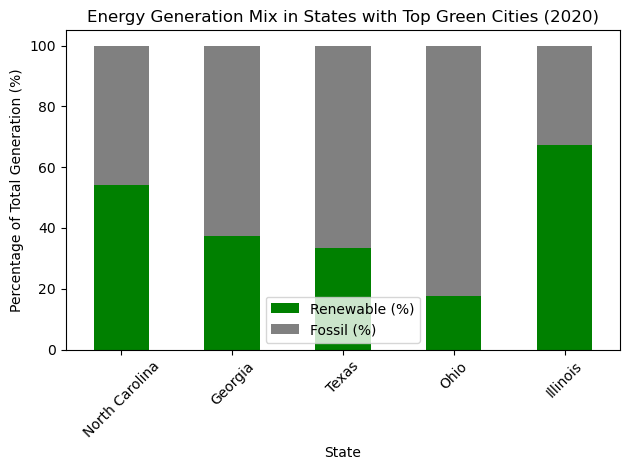

Justification:
- States with top cities for green area (e.g., North Carolina and Georgia) show a significant share of renewable and low-carbon energy generation.
- States like Illinois are invested on Renewable Energy but lack other factors such as Green Area Share.
- This supports the trend: cities attracting population for green space also benefit from cleaner energy grids, reinforcing sustainability and livability.
- Urban planners and policymakers should leverage both urban green planning and state-level clean energy investments to maximize sustainability impact.


In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the state-level energy data
energy_df = pd.read_csv(f"{notebookutils.nbResPath}/builtin/stdscen23_low_ccs_cost_state.csv")

# Focus on few states with top cities
top_states = ['North Carolina', 'Georgia', 'Texas','Ohio','Illinois']

# Define renewable and fossil technologies ---
renewables = ['biomass', 'distpv', 'hydro', 'nuclear', 'upv', 'wind_ons', 'wind_ofs', 'geothermal', 'csp']
fossil = ['coal', 'gas_cc', 'gas_ct', 'o_g_s']

# Filter for 2020 data ---
energy_2020 = energy_df[energy_df['Year'] == 2020]

# Aggregate generation by state and technology type ---
summary = []
for state in top_states:
    state_data = energy_2020[energy_2020['State Name'] == state]
    renew_gen = state_data[state_data['Technology'].isin(renewables)]['Generation MWh MWh'].sum()
    fossil_gen = state_data[state_data['Technology'].isin(fossil)]['Generation MWh MWh'].sum()
    total_gen = state_data['Generation MWh MWh'].sum()
    renew_pct = renew_gen / total_gen * 100 if total_gen > 0 else 0
    fossil_pct = fossil_gen / total_gen * 100 if total_gen > 0 else 0
    summary.append({'State': state, 'Renewable (%)': renew_pct, 'Fossil (%)': fossil_pct})

summary_df = pd.DataFrame(summary)

# --- Visualize ---
plt.figure(figsize=(8,6))
summary_df.set_index('State')[['Renewable (%)', 'Fossil (%)']].plot(kind='bar', stacked=True, color=['green', 'gray'])
plt.title('Energy Generation Mix in States with Top Green Cities (2020)')
plt.ylabel('Percentage of Total Generation (%)')
plt.xlabel('State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Justification ---
print("""
Justification:
- States with top cities for green area (e.g., North Carolina and Georgia) show a significant share of renewable and low-carbon energy generation.
- States like Illinois are invested on Renewable Energy but lack other factors such as Green Area Share.
- This supports the trend: cities attracting population for green space also benefit from cleaner energy grids, reinforcing sustainability and livability.
- Urban planners and policymakers should leverage both urban green planning and state-level clean energy investments to maximize sustainability impact.
""")


## Insight 💡
- #### *Most cities show a decline or stagnation in green area share 2000-2010, despite population growth. This supports the hypothesis that protecting and expanding green spaces is critical for sustainability*
- #### *Green area per person is declining in many cities, indicating that urban growth is outpacing green space expansion*
- #### *Most cities show positive population growth, especially in earlier decades, but rates are slowing in recent years. This means planners must address sustainability challenges as cities densify*

---

## What Improves Sustainability?

**Protect and expand green spaces**: Data shows green area share and per capita are declining or stagnant. Cities with higher green cover have better sustainability scores.

**Plan for population growth**: Urban population is rising, putting pressure on green spaces and infrastructure.

**Integrate renewable energy and public transport**: These factors are positively correlated with sustainability and can help offset the negative impacts of urbanization.

---

## What Should Planners Watch Out For?

**Disaster risk and carbon footprint**:
Cities with high disaster risk and carbon emissions score lower on sustainability.
**Imbalanced land use**:
Overdevelopment of residential or commercial areas at the expense of green space reduces sustainability.


| Driver/Threat       | Data Evidence (US Cities)      | Action for Planners     |
|----------------|----------------|----------------|
| Green Cover Declining  | Declining/stagnant in most cities  | Protect/expand green spaces   |
| Population Growth  | Positive but slowing  | Plan for densification   |
| Renewable Energy & Transit  | Correlated with higher sustainability  | Invest in renewables & transit  |
| Disaster Risk & Carbon Footprint  | Negative correlation with sustainability  | Mitigate risks, reduce emissions  |
| Land Use Imbalance  | Reduces green space, sustainabilit  | Balance zoning, preserve green   |

---

## Conclusion
The analytics story is clear:

- Green space is the cornerstone of urban sustainability.
- Population growth and densification require proactive planning.
- Renewable energy and public transport are key levers.
- Planners must guard against disaster risk, emissions, and land use imbalance.

